In [3]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 300

data = {
    'Project_Duration': np.random.randint(1, 24, n),
    'Team_Size': np.random.randint(2, 20, n),
    'Experience_Level': np.random.randint(1, 10, n),
    'Complexity_Score': np.random.randint(1, 10, n),
    'Client_Rating': np.random.randint(1, 6, n)
}

df = pd.DataFrame(data)

# Target Variable
df['Project_Status'] = np.where(
    (df['Experience_Level'] >= 5) &
    (df['Client_Rating'] >= 3) &
    (df['Complexity_Score'] <= 7),
    'Successful',
    'Delayed'
)

print(df.head())

   Project_Duration  Team_Size  Experience_Level  Complexity_Score  \
0                 7          2                 8                 4   
1                20         17                 2                 6   
2                15         13                 5                 2   
3                11         15                 7                 5   
4                 8          7                 8                 1   

   Client_Rating Project_Status  
0              2        Delayed  
1              5        Delayed  
2              2        Delayed  
3              5     Successful  
4              1        Delayed  


In [4]:
df.to_csv("CoreTech_Project_Status.csv", index=False)

In [23]:
from google.colab import files
files.download("CoreTech_Project_Status.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
df = pd.read_csv("CoreTech_Project_Status.csv")

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Project_Status'] = le.fit_transform(df['Project_Status'])

In [7]:
X = df.drop('Project_Status', axis=1)

y = df['Project_Status']

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [9]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [10]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [12]:
from sklearn.metrics import accuracy_score

print("Logistic Regression:",
      accuracy_score(y_test, y_pred_lr))

print("Decision Tree:",
      accuracy_score(y_test, y_pred_dt))

print("Random Forest:",
      accuracy_score(y_test, y_pred_rf))

Logistic Regression: 0.85
Decision Tree: 1.0
Random Forest: 1.0


In [13]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_lr)
print(cm_dt)
print(cm_rf)

[[40  5]
 [ 4 11]]
[[45  0]
 [ 0 15]]
[[45  0]
 [ 0 15]]


In [14]:
from sklearn.metrics import classification_report

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))

print("Decision Tree")
print(classification_report(y_test, y_pred_dt))

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.89      0.90        45
           1       0.69      0.73      0.71        15

    accuracy                           0.85        60
   macro avg       0.80      0.81      0.80        60
weighted avg       0.85      0.85      0.85        60

Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       1.00      1.00      1.00        15

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       1.00      1.00      1.00        15

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00   

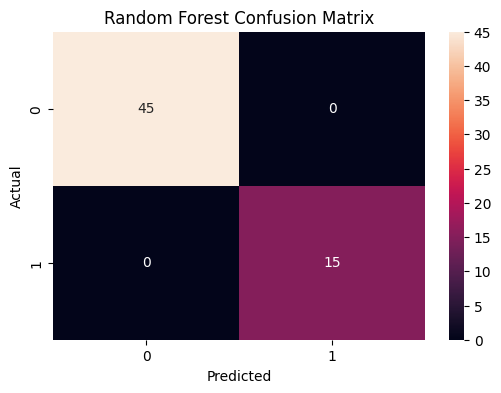

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("confusion_matrix.png")
plt.show()

In [20]:
files.download("confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression      0.85
1        Decision Tree      1.00
2        Random Forest      1.00
